# Making predictions for U-component of wind (U10)

In this notebook, we use our pretrained downscaling model to make predictions on the NAM test dataset. The test data is passed through the model to generate high-resolution predictions, which are then evaluated against the ground truth (uWRF) to assess model performance.

In [1]:
import torch as pt
import xarray as xr
import pandas as pd
import numpy as np
import torch_dl4ds as dds
from torch_dl4ds import PostUpsamplingNet
from torch_dl4ds import Predictor

In [2]:
# The pretrained model contains learned weights and biases obtained by minimizing the loss function during training

model_path = '/home/gvaillant1/downscaling/pretrained-models/U10/U10-Best-Model/u10_model.pth'

model = PostUpsamplingNet(
    backbone_block='resnet', 
    upsampling='spc',                  
    scale=3,               
    lr_size=(40, 40),           
    n_channels=5,                    
    n_filters=8,
    n_blocks=8,
    activation='relu',
    localcon_layer=True
)

model.load_state_dict(pt.load(model_path, map_location='cpu')) 
model.eval()

PostUpsamplingNet(
  (initial_conv): Conv2d(5, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (backbone): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv1x1): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
    )
    (2): ResidualBlock(
      (conv1): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv1x1): Conv2d(16, 24, kernel_size=(1, 1), stride=(1, 1))
    )
    (3): ResidualBlock(
      (conv1): Conv2d(24, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)

# Data

Input: Low-resolution NAM test set (unseen data)

In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [4]:
uwrf_list = [uwrf_test]
nam_list = [nam_test]

for ds in uwrf_list: 
            
            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'


for ds in nam_list:

            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'

In [5]:
uwrf_list = [uwrf_test]
nam_list = [nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

# Scaling the data

Here we scale the test set using the same scaling factor we used with the training set.
We use the scale from the training set to avoid data leakage.

In [6]:
var_list = ['U10']
pred_var_list = ['PSFC', 'T2', 'V10', 'PBLH']

for var in var_list:

    # HR (uWRF) training variable
    var_hr_train = uwrf_train[var]

    # HR predictors (stacked channels: e.g., PSFC, U10, V10, SWDOWN, PBLH)
    pred_var_hr_train = np.stack([uwrf_train[p] for p in pred_var_list], axis=1)


    # Fit scalers on TRAINING data
    var_scaler_train = dds.TorchStandardScaler(axis=None)
    var_scaler_train.fit(var_hr_train)  # Fit scaler for target variable

    # Predictor scaler is fitted per-channel below, but also keep full HR stack
    pred_var_scaler_train = dds.TorchStandardScaler(axis=None)
    pred_var_scaler_train.fit(pred_var_hr_train)


# Prepare TEST data
for var in var_list:
    # HR (uWRF) test variable (ground truth)
    var_hr_test = uwrf_test[var]

    # HR predictors (for evaluation)
    pred_var_hr_test = np.stack([uwrf_test[p] for p in pred_var_list], axis=1)

    # LR (NAM) test variable (input)
    var_lr_test = nam_test[var]

    # LR predictors (for model input)
    pred_var_lr_test = np.stack([nam_test[p] for p in pred_var_list], axis=1)

    # Scale TEST data using TRAIN scalers
    y_test = var_scaler_train.transform(var_hr_test)  # scaled HR target
    x_test = var_scaler_train.transform(var_lr_test)  # scaled LR target

    y_test = np.expand_dims(y_test, axis=1)  # add channel dim [B,1,H,W]
    x_test = np.expand_dims(x_test, axis=1)

    # Scale predictors channel-wise
    pred_var_scalers = []
    x_z_test_list = []  # scaled LR predictors
    y_z_test_list = []  # scaled HR predictors (for eval)

    for i in range(pred_var_hr_train.shape[1]):
        scaler = dds.TorchStandardScaler(axis=None)
        scaler.fit(pred_var_hr_train[:, i])  # Fit per predictor channel (training HR)
        pred_var_scalers.append(scaler)

        y_z_test_list.append(np.expand_dims(scaler.transform(pred_var_hr_test[:, i]), axis=1))
        x_z_test_list.append(np.expand_dims(scaler.transform(pred_var_lr_test[:, i]), axis=1))

    # Final scaled predictors
    pred_var_hr_test = np.concatenate(y_z_test_list, axis=1)  # HR predictors (eval)
    pred_var_lr_test = np.concatenate(x_z_test_list, axis=1)  # LR predictors (model input)

# Check shape

In [7]:
print(f'HR test set predictor variable shape: {pred_var_hr_test.shape}')
print(f'LR test set predictor variable shape: {pred_var_lr_test.shape}')
print('')
print(f'LR (x_test) test set shape: {x_test.shape}')
print(f'HR (y_test) test set shape: {y_test.shape}')

HR test set predictor variable shape: (578, 4, 120, 120)
LR test set predictor variable shape: (578, 4, 40, 40)

LR (x_test) test set shape: (578, 1, 40, 40)
HR (y_test) test set shape: (578, 1, 120, 120)


In [8]:
test_array = x_test # (578, 1, 40, 40)
test_predictors = pred_var_lr_test # (578, 5, 40, 40)

predictor = Predictor(
    trainer=model,
    array=test_array,
    scale=3,
    array_in_hr=False, 
    predictors=test_predictors,
    interpolation='inter_area',
    batch_size=32,
    scaler=None, 
    save_path=None, 
    save_fname='y_hat.npy',
    return_lr=False,
    device='cpu'
)

# Making predictions on the scaled data (numpy array)
y_pred_normalized = predictor.run()

# Inverse scaling of the predictions (y_pred is now using Kelvin) 
y_pred = var_scaler_train.inverse_transform(y_pred_normalized)
y_true = var_scaler_train.inverse_transform(y_test)

In [9]:
import xarray as xr
import numpy as np
import torch
import pandas as pd


if isinstance(y_pred, torch.Tensor):
    y_pred = y_pred.cpu().numpy()


y_pred = np.squeeze(y_pred, axis=1)


times = uwrf_test['time'].values            # (2697,)
y_coords = uwrf_test['y'].values            # (120,)
x_coords = uwrf_test['x'].values            # (120,)
lat2d = uwrf_test['latitude'].values        # (120, 120)
lon2d = uwrf_test['longitude'].values       # (120, 120)

# Create DataArray matching uWRF format
U10_da = xr.DataArray(
    data=y_pred,
    dims=("time", "y", "x"),
    coords={
        "time": times,
        "y": y_coords,
        "x": x_coords,
        "latitude": (("y", "x"), lat2d),
        "longitude": (("y", "x"), lon2d),
    },
    name="U10"
)



In [10]:
print(f"shape of y_pred: {y_pred.shape}")
y_true = np.squeeze(y_true, axis=1)  # Now shape: (578, 120, 120)
print(f"shape of y_true: {y_true.shape}")

shape of y_pred: (578, 120, 120)
shape of y_true: (578, 120, 120)


In [11]:
# Compute MAE in m/s
mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
# Compute MAPE (in %)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

MSE: 1.86
MAE: 1.41
MAPE: 715.58%


In [12]:
y_pred_normalized.shape

(578, 1, 120, 120)

In [13]:
y_test.shape

(578, 1, 120, 120)

# MAE of normalized data

In [14]:
#mae of scaled data:

mae_normalized = np.mean(np.abs(y_pred_normalized - y_test))

print(mae_normalized)

0.28762674


# Visualize results

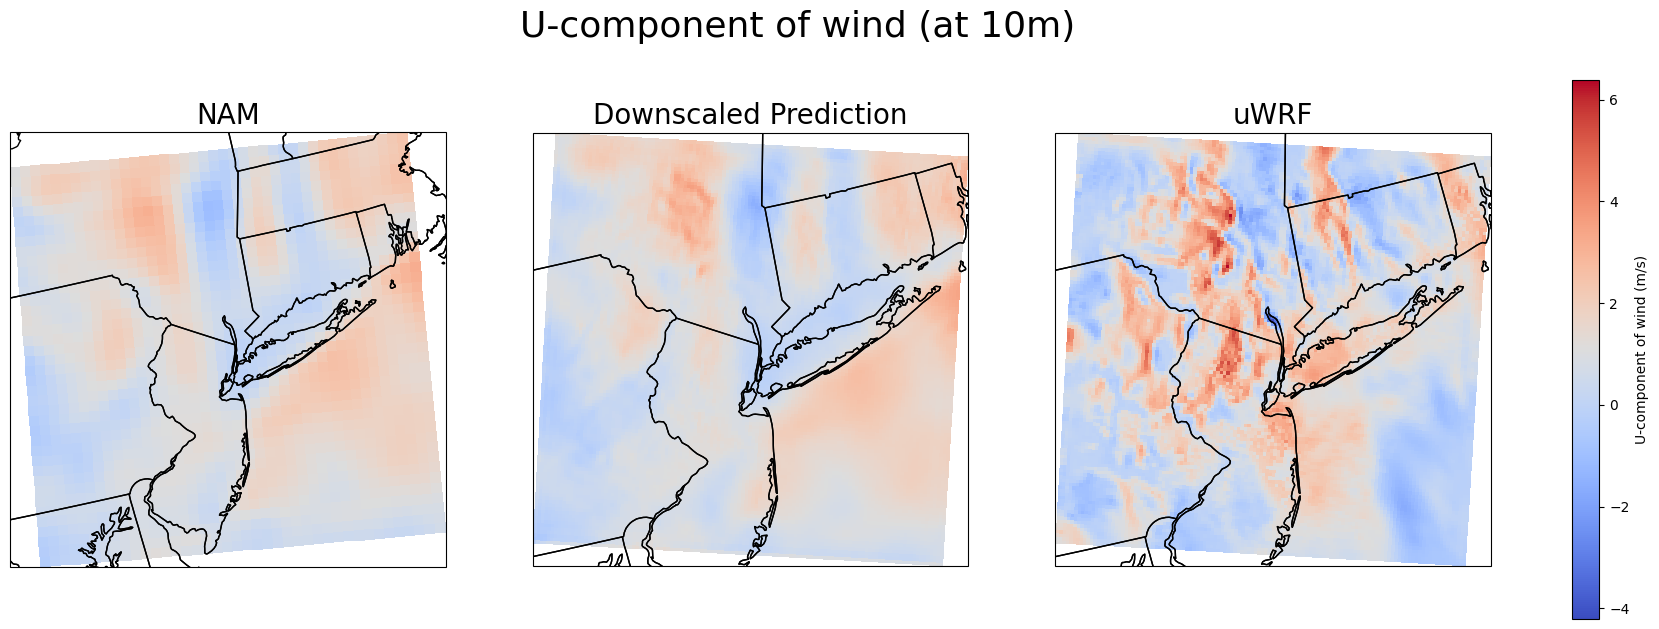

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature


# Extract data
nam = nam_test.U10  # input
results= U10_da #output
uwrf = uwrf_test.U10  # target


time_idx = 50 # CHANGE

lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[time_idx,:,:].values

# Prediction values — want to be the same resolution as uWRF
t2_pred = results[time_idx, :, :]

# common color limits
vmin = min(t2_nam.min(), t2_pred.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_pred.max(), t2_uwrf.max())


fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title(f'NAM', fontsize=20)
axes[0].coastlines()
#axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)

# Plot Prediction
im1 = axes[1].pcolormesh(lon_uwrf, lat_uwrf, t2_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[1].set_title(f'Downscaled Prediction', fontsize=20)
axes[1].coastlines()
#axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[2].set_title(f'uWRF', fontsize=20)
axes[2].coastlines()
#axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('U-component of wind (m/s)')

# Add main title
fig.suptitle(f'U-component of wind (at 10m)', fontsize=26)

plt.show()

In [16]:
results.to_netcdf("/home/gvaillant1/downscaled_U10.nc")